In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Dataset Overview

In [6]:
df = pd.read_csv(r"C:\Sigit\Pricing_Dataset\data\pricing_dataset.csv")
df.head()

,Month,Customer,Region,SalesChannel,CustomerSegment,Product,Category,Qty,Price,Cost,CompetitorPrice,PriceIncreaseHistory,PromotionFlag,Revenue,TotalCost,Profit,MarginPct
0,2025-01,Customer 01,East Indonesia,Modern Trade,Distributor,SKU 06,Snack,832,22925,15078,23765,5%,N,19073600,12544896,6528704,0.3423
1,2025-01,Customer 01,East Indonesia,General Trade,Distributor,SKU 19,Personal Care,84,39096,25986,37623,0%,N,3284064,2182824,1101240,0.3353
2,2025-01,Customer 01,East Indonesia,Modern Trade,Distributor,SKU 02,Beverage,758,9345,6657,10142,0%,N,7083510,5046006,2037504,0.2876
3,2025-01,Customer 01,East Indonesia,General Trade,Distributor,SKU 08,Snack,1074,32172,26095,32427,8%,N,34552728,28026030,6526698,0.1889
4,2025-01,Customer 01,East Indonesia,General Trade,Distributor,SKU 01,Beverage,238,23957,15218,21918,5%,N,5701766,3621884,2079882,0.3648


In [10]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Month                 4096 non-null   object 
 1   Customer              4096 non-null   object 
 2   Region                4096 non-null   object 
 3   SalesChannel          4096 non-null   object 
 4   CustomerSegment       4096 non-null   object 
 5   Product               4096 non-null   object 
 6   Category              4096 non-null   object 
 7   Qty                   4096 non-null   int64  
 8   Price                 4096 non-null   int64  
 9   Cost                  4096 non-null   int64  
 10  CompetitorPrice       4096 non-null   int64  
 11  PriceIncreaseHistory  4096 non-null   object 
 12  PromotionFlag         4096 non-null   object 
 13  Revenue               4096 non-null   int64  
 14  TotalCost             4096 non-null   int64  
 15  Profit               

,Qty,Price,Cost,CompetitorPrice,Revenue,TotalCost,Profit,MarginPct
count,4096.000000,4096.000000,4096.000000,4096.000000,4.096000e+03,4.096000e+03,4.096000e+03,4096.000000
mean,658.974121,26104.230713,18904.439697,26137.564209,1.723548e+07,1.249920e+07,4.736285e+06,0.275015
std,351.821591,13937.492645,10274.671197,14046.762932,1.397143e+07,1.026009e+07,4.146608e+06,0.072247
min,48.000000,8075.000000,4860.000000,7377.000000,4.370760e+05,2.659500e+05,1.192980e+05,0.150100
25%,365.000000,13525.750000,9365.250000,13420.000000,6.645176e+06,4.810222e+06,1.687951e+06,0.212875
50%,659.000000,24459.500000,17414.000000,24308.000000,1.284810e+07,9.341336e+06,3.394793e+06,0.275200
75%,957.000000,39045.750000,27707.500000,39458.750000,2.452509e+07,1.770592e+07,6.609454e+06,0.335625
max,1359.000000,53002.000000,43333.000000,57634.000000,6.826099e+07,5.379455e+07,2.470212e+07,0.400100


## 2. Summary Dataset

In [24]:
total_revenue = df["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 70596542061


In [25]:
total_profit =df["Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 19399823761


In [26]:
total_product = df["Product"].nunique()
print("Total Unique Products:", total_product)

Total Unique Products: 20


In [28]:
total_customers = df["Customer"].nunique()
print("Total Unique Customers:", total_customers)

Total Unique Customers: 30


In [29]:
total_transactions = len(df)
print("Total Transactions:", total_transactions)

Total Transactions: 4096


In [31]:
summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Profit", "Total Unique Products", "Total Unique Customers", "Total Transactions"],
    "Value": [total_revenue, total_profit, total_product, total_customers, total_transactions]
})
summary

,Metric,Value
0,Total Revenue,70596542061
1,Total Profit,19399823761
2,Total Unique Products,20
3,Total Unique Customers,30
4,Total Transactions,4096


## 3. Competitor Price Analysis

In [46]:
df["PriceGap"] = (df["Price"] - df["CompetitorPrice"])
price_gap = (df.groupby("Product")["PriceGap"].mean().sort_values())
price_gap

## if negative results, it means our price is lower than competitor, if positive, it means our price is higher than competitor

Product
SKU 04   -193.357895
SKU 17   -188.741627
SKU 16   -164.099502
SKU 08   -133.159420
SKU 15    -79.546341
SKU 20    -77.375610
SKU 06    -62.125604
SKU 10    -56.465000
SKU 18    -52.179104
SKU 05    -42.203883
SKU 03    -33.857143
SKU 09    -23.878505
SKU 02     -4.477387
SKU 14     14.310185
SKU 11     19.023041
SKU 13     25.630769
SKU 12     47.900943
SKU 01     73.650718
SKU 07    104.229268
SKU 19    144.594059
Name: PriceGap, dtype: float64

Text(0.5, 1.0, 'Average Price Gap by Product')

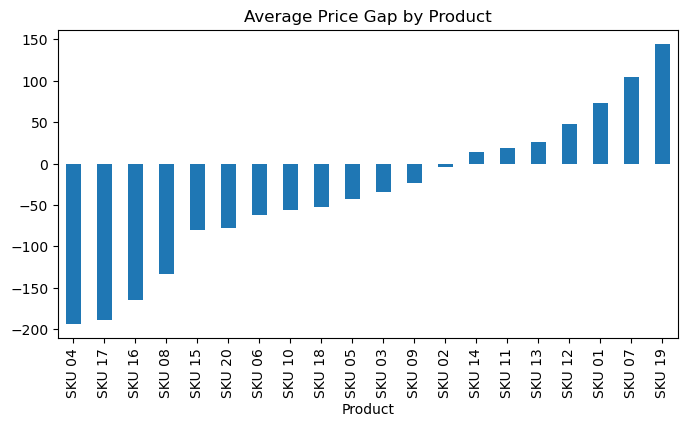

In [44]:
price_gap.plot(kind="bar", figsize=(8, 4))
plt.title("Average Price Gap by Product")

### insights of Competitor Analysis :

Several products are currently priced below competitor levels, particularly SKU 04, SKU 17, and SKU 16. 
These products may represent potential pricing opportunities, as the company could consider selective price increases while remaining competitively positioned in the market

On the other hand, products such as SKU 19 and SKU 07 are currently priced above competitors, indicating a need for closer monitoring to avoid potential pricing pressure or volume decline

